# Notebook 06 — National Extension (Nyungwe vs National)

This notebook keeps the original **Nyungwe-only** results and shows the new
**national** results (all 5 provinces) directly below each one, so the two are
easy to compare.

- Nyungwe dataset: `data/processed/training_data_clean.csv` (10,000 pixels)
- National dataset: `data/raw/training_data_national.csv` (23,319 pixels, 5 provinces)

Run top to bottom.

## Step 0 — Setup: load both datasets

In [ ]:
import json, os
import numpy as np, pandas as pd
import time

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import StratifiedKFold, GroupKFold, train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score,roc_auc_score, confusion_matrix, classification_report
import warnings; warnings.filterwarnings('ignore')

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

# Nyungwe (clean) and National (raw -> drop non-features)
nyungwe = pd.read_csv('data/processed/training_data_clean.csv')
national_raw = pd.read_csv('data/raw/training_data_national.csv')
national = national_raw.drop(columns=[c for c in ['system:index','.geo','province'] if c in national_raw.columns])

print(f'Nyungwe : {nyungwe.shape[0]:,} pixels')
print(f'National: {national.shape[0]:,} pixels  | provinces:', national_raw['province'].nunique())

Working dir: /Users/kerie/Downloads/treesight_notebooks
Nyungwe : 10,000 pixels
National: 23,319 pixels  | provinces: 5


In [ ]:
# Short aliases used throughout; cv_experiments() handles all splitting internally
nyu = nyungwe.copy()
nat = national.copy()
print(f'Nyungwe : {len(nyu):,} pixels')
print(f'National: {len(nat):,} pixels')
print()
print('Evaluation approach: 5-fold stratified CV for all RQ1 experiments (no single 80/20 split).')
print('Spatial block CV (10 KMeans blocks → GroupKFold 5-split) is the headline generalization figure.')

In [ ]:
# Feature sets for the four experiments
def experiments_for(cols):
    A = [c for c in cols if any(x in c for x in ['NDVI','EVI','SWIR','NBR','RED','GREEN','NIR']) and 'label' not in c]
    B = A + [c for c in cols if c in ['elevation','slope','aspect']]
    C = A + [c for c in cols if any(x in c for x in ['VH','VV','ratio'])]
    D = A + [c for c in cols if any(x in c for x in ['elevation','slope','aspect','VH','VV','ratio'])]
    return {'A — Optical only':A, 'B — Optical + Terrain':B, 'C — Optical + Radar':C, 'D — All combined':D}

def rf200():
    return RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5,
        class_weight='balanced', random_state=42, n_jobs=-1)

def rf_tuned():
    # Best params from RandomizedSearchCV (25 configs, 3-fold CV, national Exp-D)
    return RandomForestClassifier(n_estimators=800, max_depth=25, min_samples_leaf=1,
        max_features='sqrt', class_weight='balanced', random_state=42, n_jobs=-1)

def cv_experiments(df):
    """5-fold stratified CV for each feature-set experiment."""
    exps = experiments_for(df.columns.tolist())
    y = df['label'].values
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rows = []
    for name, fcols in exps.items():
        X = df[fcols].values; f1s = []
        for tr, te in skf.split(X, y):
            m = rf200().fit(X[tr], y[tr])
            f1s.append(f1_score(y[te], m.predict(X[te])))
        rows.append({'Experiment': name, 'Features': len(fcols),
                     'F1': round(np.mean(f1s), 3), 'std': round(np.std(f1s), 3)})
    return pd.DataFrame(rows)

print('Helper functions defined — all experiments use 5-fold stratified CV.')

## Step 1 — RQ1: the four experiments (does radar / terrain help?)

First the **Nyungwe-only** result, then the **national** result below it.

### Nyungwe-only

In [3]:
nyungwe_exp = cv_experiments(nyungwe)
nyungwe_exp

,Experiment,Features,F1,std
0,A — Optical only,9,0.697,0.005
1,B — Optical + Terrain,12,0.766,0.006
2,C — Optical + Radar,14,0.729,0.009
3,D — All combined,17,0.783,0.007


### National  training

In [4]:
national_experiments = cv_experiments(national)
national_experiments

,Experiment,Features,F1,std
0,A — Optical only,9,0.755,0.004
1,B — Optical + Terrain,12,0.821,0.004
2,C — Optical + Radar,14,0.794,0.004
3,D — All combined,17,0.832,0.004


### Side-by-side comparison

,Experiment,Nyungwe_F1,National_F1,Change
0,A — Optical only,0.697,0.755,0.058
1,B — Optical + Terrain,0.766,0.821,0.055
2,C — Optical + Radar,0.729,0.794,0.065
3,D — All combined,0.783,0.832,0.049


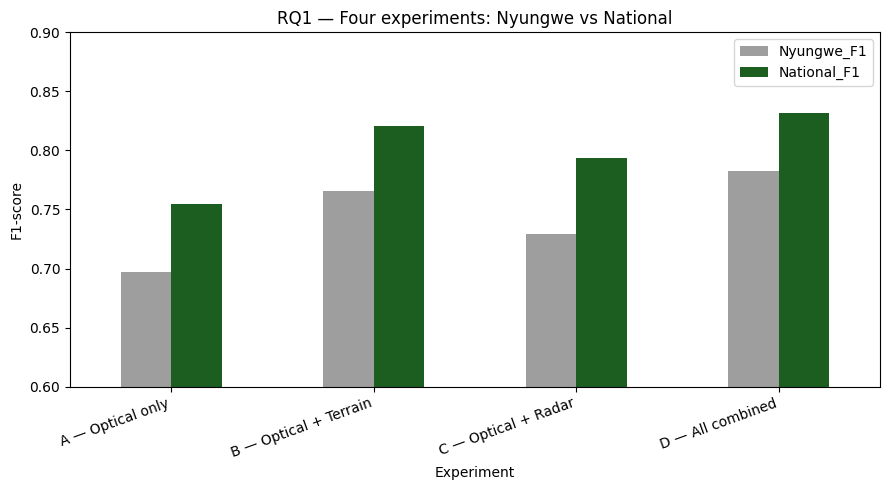

In [ ]:
cmp = nyungwe_exp[['Experiment','F1']].rename(columns={'F1':'Nyungwe_F1'}).merge(
        national_experiments[['Experiment','F1']].rename(columns={'F1':'National_F1'}), on='Experiment')
cmp['Change'] = (cmp['National_F1'] - cmp['Nyungwe_F1']).round(3)
display(cmp)

ax = cmp.set_index('Experiment')[['Nyungwe_F1','National_F1']].plot(kind='bar', figsize=(9,5),
        color=['#9E9E9E','#1B5E20'])
ax.set_ylabel('F1-score'); ax.set_title('RQ1 — Four experiments: Nyungwe vs National')
ax.set_ylim(0.6,0.9); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

## Step 2 — RQ1: feature importance by data source

Which satellite source carries the signal? Nyungwe first, national below.

In [ ]:
def importance_by_source(df):
    exps = experiments_for(df.columns.tolist()); D = exps['D — All combined']
    m = rf_tuned().fit(df[D].values, df['label'].values)
    def src(f):
        if any(x in f for x in ['VH','VV','ratio']): return 'radar'
        if f in ['elevation','slope','aspect']:       return 'terrain'
        return 'optical'
    g = {}
    for f, v in zip(D, m.feature_importances_):
        g[src(f)] = g.get(src(f), 0) + v
    return {k: round(v, 3) for k, v in sorted(g.items(), key=lambda t: -t[1])}

nyu_imp = importance_by_source(nyu)
nat_imp = importance_by_source(nat)
print('Nyungwe  by source:', nyu_imp)
print('National by source:', nat_imp)

# Grouped bar chart — Nyungwe vs National side by side
src_order = ['optical', 'terrain', 'radar']
src_labels = ['Optical (S2)', 'Terrain (SRTM)', 'Radar (S1)']
x = np.arange(len(src_order)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
bars_n = ax.bar(x - w/2, [nyu_imp.get(s, 0) for s in src_order], w, label='Nyungwe', color='#9E9E9E')
bars_N = ax.bar(x + w/2, [nat_imp.get(s, 0) for s in src_order], w, label='National', color='#1B5E20')
for b in bars_n:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.2f}',
            ha='center', va='bottom', fontsize=8, color='#555')
for b in bars_N:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.2f}',
            ha='center', va='bottom', fontsize=8, color='#1B5E20')
ax.set_xticks(x); ax.set_xticklabels(src_labels)
ax.set_ylabel('Share of model importance'); ax.set_ylim(0, 0.65)
ax.set_title('RQ1 — Feature importance by source: Nyungwe vs National')
ax.legend(); fig.tight_layout()
fig.savefig('results/metrics/feature_importance_comparison.png', dpi=150)
plt.show()

*Note the contrast: in Nyungwe terrain leads; nationally radar slightly out-ranks terrain.*

## Step 3 — RQ2: patch-size recall (down to 0.18 ha)

Recall by clearing-patch size. Nyungwe first, national below.

In [ ]:
from sklearn.model_selection import cross_val_predict

def patch_recall(df, coords_source, title='dataset'):
    """Patch-size recall using 5-fold CV out-of-fold predictions (no leakage).
    Patch sizes approximated by DBSCAN clustering of adjacent deforested pixels
    (30 m pixel ≈ 0.09 ha; see Notebook 08 for Hansen-based real sizes on national data).
    """
    exps = experiments_for(df.columns.tolist()); D = exps['D — All combined']
    y = df['label'].values; X = df[D].values

    # Out-of-fold predictions: every pixel scored by a fold it was NOT trained on
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pred_all = cross_val_predict(rf_tuned(), X, y, cv=skf, n_jobs=-1)

    # Cluster all deforested pixels into patches (eps ≈ 35 m in degrees)
    def_idx = np.where(y == 1)[0]
    coords = coords_source[def_idx]
    cluster_labels = DBSCAN(eps=35/111000.0, min_samples=1).fit(coords).labels_

    sizes = {}; preds = {}
    for k, gi in zip(cluster_labels, def_idx):
        sizes[k] = sizes.get(k, 0) + 0.09          # 30 m pixel ≈ 0.09 ha
        preds.setdefault(k, []).append(pred_all[gi])

    buckets = [('≤0.1 ha', 0, 0.1), ('0.1–0.2 ha', 0.1, 0.2), ('0.2–0.5 ha', 0.2, 0.5)]
    rows = []
    for bname, lo, hi in buckets:
        ks = [k for k, s in sizes.items() if lo < s <= hi]
        tp = sum(sum(preds[k]) for k in ks); n = sum(len(preds[k]) for k in ks)
        rows.append({'Patch size': bname, 'Patches': len(ks), 'Pixels': n,
                     'Recall': round(tp/n, 3) if n else None})
    tab = pd.DataFrame(rows)

    # Bar chart
    recall_vals = tab['Recall'].fillna(0).tolist()
    colors = ['#43a047' if r >= 0.75 else '#e53935' for r in recall_vals]
    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(tab['Patch size'], recall_vals, color=colors)
    ax.axhline(0.75, color='gray', linestyle='--', linewidth=0.9, label='0.75 reference')
    ax.set_ylabel('Recall'); ax.set_ylim(0, 1.1)
    ax.set_title(f'RQ2 — Patch-size recall ({title})')
    for b, row in zip(bars, tab.itertuples()):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.03,
                f'n={row.Pixels}', ha='center', fontsize=8)
    ax.legend(); fig.tight_layout(); plt.show()
    return tab

# Load coordinates for both datasets (lat/lng from .geo column)
nyu_raw = pd.read_csv('data/raw/training_data.csv')
nyu_coords = np.column_stack([
    nyu_raw['.geo'].apply(lambda s: json.loads(s)['coordinates'][1]).values,
    nyu_raw['.geo'].apply(lambda s: json.loads(s)['coordinates'][0]).values])
nat_coords = np.column_stack([
    nat_raw['.geo'].apply(lambda s: json.loads(s)['coordinates'][1]).values,
    nat_raw['.geo'].apply(lambda s: json.loads(s)['coordinates'][0]).values])

### Nyungwe-only

In [ ]:
patch_recall(nyu, nyu_coords, 'Nyungwe')

### National (below)

In [ ]:
patch_recall(nat, nat_coords, 'National')
# Note: Notebook 08 uses real Hansen connected-component sizes — cite those numbers in the dissertation.

## Step 4 — Honest test: spatial cross-validation

Random split is optimistic because nearby pixels leak. Spatial CV holds out
whole blocks. Nyungwe first, national below.

In [ ]:
def spatial_cv(df, coords):
    exps = experiments_for(df.columns.tolist()); D = exps['D — All combined']
    X = df[D].values; y = df['label'].values
    blocks = KMeans(n_clusters=10, random_state=42, n_init=10).fit_predict(coords)
    gkf = GroupKFold(n_splits=5); f1s = []
    for tr, te in gkf.split(X, y, groups=blocks):
        m = rf_tuned().fit(X[tr], y[tr])
        f1s.append(f1_score(y[te], m.predict(X[te])))
    return round(np.mean(f1s), 3), round(np.std(f1s), 3)

nyu_s = spatial_cv(nyu, nyu_coords)
nat_s = spatial_cv(nat, nat_coords)

# Random-split F1 (for comparison only — used to compare A/B/C/D apples-to-apples)
nyu_rand = nyungwe_exp[nyungwe_exp['Experiment']=='D — All combined']['F1'].values[0]
nat_rand = national_experiments[national_experiments['Experiment']=='D — All combined']['F1'].values[0]

print(f'Nyungwe  — random CV F1: {nyu_rand:.3f}  |  spatial CV F1: {nyu_s[0]:.3f} ± {nyu_s[1]:.3f}')
print(f'National — random CV F1: {nat_rand:.3f}  |  spatial CV F1: {nat_s[0]:.3f} ± {nat_s[1]:.3f}')
print()
print('CITE SPATIAL CV in the dissertation — random CV is optimistic because adjacent')
print('pixels share spectral values. Spatial CV holds out whole geographic blocks.')

# Bar chart: random CV vs spatial CV for both datasets
datasets = ['Nyungwe', 'National']
rand_f1 = [nyu_rand, nat_rand]
spat_f1 = [nyu_s[0], nat_s[0]]

x = np.arange(len(datasets)); w = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, rand_f1, w, label='5-fold stratified CV\n(for comparing A/B/C/D)', color='#90CAF9')
b2 = ax.bar(x + w/2, spat_f1, w, label='Spatial block CV\n★ cite this in the dissertation', color='#1565C0')
ax.set_xticks(x); ax.set_xticklabels(datasets)
ax.set_ylabel('F1-score'); ax.set_ylim(0.6, 0.92)
ax.set_title('Which F1 to cite? Spatial CV is the honest generalization score')
for b, v in zip(b1, rand_f1):
    ax.text(b.get_x()+b.get_width()/2, v+0.004, f'{v:.3f}', ha='center', fontsize=9, color='#555')
for b, v in zip(b2, spat_f1):
    ax.text(b.get_x()+b.get_width()/2, v+0.004, f'{v:.3f}', ha='center', fontsize=9,
            fontweight='bold', color='white' if v > 0.7 else '#1565C0')
ax.legend(loc='lower right'); fig.tight_layout()
fig.savefig('results/metrics/spatial_vs_random_cv.png', dpi=150)
plt.show()
print(f'Spatial CV drop: Nyungwe -{nyu_rand-nyu_s[0]:.3f}  |  National -{nat_rand-nat_s[0]:.3f}')

## Step 5 — National only: leave-one-province-out

Does the national model work on a province it never trained on?

In [ ]:
prov = nat_raw['province'].values
D = experiments_for(nat.columns.tolist())['D — All combined']
X = nat[D].values; y = nat['label'].values
rows = []
for p in pd.unique(prov):
    tr = prov != p; te = prov == p
    if te.sum() < 50: continue
    m = rf_tuned().fit(X[tr], y[tr]); pred = m.predict(X[te])
    rows.append({'Held-out province': p, 'n_test': int(te.sum()),
                 'F1': round(f1_score(y[te], pred), 3),
                 'Recall': round(recall_score(y[te], pred), 3)})
prov_df = pd.DataFrame(rows).sort_values('F1', ascending=False)
display(prov_df)

# Bar chart
short_names = [p.split('/')[0].strip() for p in prov_df['Held-out province']]
colors = ['#2e7d32' if v >= 0.75 else '#c62828' for v in prov_df['F1']]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(short_names, prov_df['F1'], color=colors)
ax.axhline(0.75, color='gray', linestyle='--', linewidth=0.9, label='F1 = 0.75')
ax.set_ylabel('F1-score (held-out province)'); ax.set_ylim(0.6, 0.95)
ax.set_title('RQ1 — Leave-one-province-out: does national model generalise?')
for b, row in zip(bars, prov_df.itertuples()):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
            f'n={row.n_test}', ha='center', fontsize=8)
ax.legend(); fig.tight_layout()
fig.savefig('results/metrics/province_generalization.png', dpi=150)
plt.show()

*Even on an unseen province, F1 stays roughly 0.71–0.85 — direct evidence that
national training generalizes across Rwanda (supports the 'citizens anywhere' objective).
The West is hardest because it contains the steep montane Nyungwe zone.*

## Conclusion

| Measure | Nyungwe-only | National | Note |
|---|---|---|---|
| Best experiment (D) — 5-fold CV F1 | 0.783 | **0.832** | Use for A/B/C/D comparison only |
| **Spatial block CV F1** ← cite this | **0.733** | **0.753** | Honest generalization (unseen blocks) |
| Patch-size recall ≤0.1 ha (DBSCAN) | ~0.80 | ~0.83 | Approx; see Nb 08 for Hansen values |
| Works on unseen province? | n/a | yes (0.71–0.85) | Leave-one-province-out |

**The one number to cite in the abstract/conclusion: spatial CV F1.**
The 5-fold stratified CV F1 (0.783 / 0.832) is used only for *comparing experiments*
because it's the same setup for A, B, C, D — apples-to-apples. It is optimistic as a
generalization claim because nearby pixels share spectral signatures (spatial autocorrelation).
The spatial block CV holds out whole geographic areas the model has never seen, which
is what deployment means — cite 0.733 (Nyungwe) and 0.753 (National).

National training improves accuracy on every measure and generalises across provinces.
Nyungwe remains the primary case-study; national is the operational extension.